<a href="https://colab.research.google.com/github/thimarArda/BinX_AI_-_ML_Training/blob/main/Convolutional%20Neural%20Networks%20Notes%20and%20Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color: #f6e8b1; color: #4a3b00; padding: 12px 16px; border-radius: 6px; margin-bottom: 12px;">
  <h1 style="margin: 0; color: #4a3b00; border: none; padding: 0;">Day 1 — Convolutional Neural Networks</h1>
</div>

# **Introduction**




In Week 6, I learned how to build a basic neural network using **Dense (fully connected) layers**. Dense networks can work well with structured/tabular data, where each feature is represented as an individual value.

However, not all data has the same structure.

For example:

* Tabular data → individual numerical or categorical features
* Text → sequences of words or tokens
* Images → spatial arrangements of pixels

When working with images, treating every pixel as an independent feature is inefficient because images contain important **spatial relationships**. Nearby pixels are usually related to each other, and useful patterns such as edges, corners, textures, and shapes can appear anywhere in an image.

This is why **Convolutional Neural Networks (CNNs)** are commonly used for image-related tasks.

A CNN is a type of neural network designed to learn patterns from images while preserving their spatial structure.

<hr style="height: 4px; background-color: #333; border: none; margin: 20px 0;" />

#  **Section 1 : Why Dense Networks Fail on Images**

An image can be represented as a grid of pixel values.

<p align="center">
<img src="https://raw.githubusercontent.com/thimarArda/BinX_AI_-_ML_Training/main/Week7_CNNs_RNN_Transformers/Day%201%20%E2%80%94%20Sprint%202%20Planning%20%26%20Convolutional%20Neural%20Networks/images/iclh-diagram-convolutional-neural-networks.png" width="500"/>

     
For example, a grayscale image with a size of `200 × 200` contains:

$$
200 \times 200 = 40,000
$$

pixel values.

For a color RGB image, there are three channels:

$$
200 \times 200 \times 3 = 120,000
$$

values.

If we feed all of these values directly into a Dense layer, every input pixel can potentially be connected to every neuron in the next layer.

For example, if the first Dense layer contains 1,000 neurons:

$$
120,000 \times 1,000 = 120,000,000
$$

weights would be required just for the first layer.

---

## This creates several problems.



### 1 Too many parameters

A Dense network can require a huge number of parameters when working with high-resolution images.

More parameters mean:

* more memory usage
* more computation
* longer training
* greater risk of overfitting

### 2 Loss of spatial information

Images are not just collections of independent numbers.

Consider an image of a cat. Pixels that are close to each other may form:

* an edge
* an eye
* a nose
* fur texture
* part of a shape

A Dense layer does not naturally understand that neighboring pixels are related.

When an image is flattened:

```text
Image
 ↓
[ pixel1, pixel2, pixel3, ... ]
```

the original two-dimensional spatial structure is lost.

### 3 Patterns can appear anywhere

Suppose a CNN learns a filter that detects a vertical edge.

That edge could appear:

* on the left side of the image
* in the center
* on the right side

We don't want to learn completely different parameters for detecting the same edge in every location.

This is one of the main ideas behind convolution.

---

# **Section 2 : Convolution**


**Convolution** is the core operation of a CNN.

Instead of connecting every pixel to every neuron, convolution looks at **small local regions** of the image.

A CNN uses a small matrix called a **filter** or **kernel**.

For example, a `3 × 3` filter could look like:

```text
[ -1  -1  -1 ]
[ -1   8  -1 ]
[ -1  -1  -1 ]
```

The filter moves across the image.

At every position, the values of the filter are multiplied by the corresponding pixel values, and the results are added together.

This is essentially a **dot product performed locally**.

For a `3 × 3` region:

```text
Image region       Filter

[ a b c ]          [ w1 w2 w3 ]
[ d e f ]    ×     [ w4 w5 w6 ]
[ g h i ]          [ w7 w8 w9 ]
```

The resulting value is:

$$
aw_1 + bw_2 + cw_3 +
dw_4 + ew_5 + fw_6 +
gw_7 + hw_8 + iw_9
$$

The filter then moves to another location and repeats the same calculation.

---

## **2.1 Convolution Concepts**

### 1. Filters / Kernels

<p align="center">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20250503115950473786/Kernels-in-convolutional-neural-network.webp" width="500"/>
</p>

A **filter**, also called a **kernel**, is a small matrix of weights used to detect a particular pattern in an image.

Examples of patterns that filters can learn include:

* horizontal edges
* vertical edges
* diagonal edges
* corners
* textures
* curves

In a real CNN, these filter values are generally **learned automatically during training**.

For example, the network might initially have random filter values.

During training:

```text
Input image
     ↓
Convolution
     ↓
Prediction
     ↓
Loss
     ↓
Backpropagation
     ↓
Update filter weights
```

The filters gradually learn which patterns are useful for the task.


---

### 2. Feature Maps

When a filter is applied to an image, it produces an output called a **feature map**.

<p align="center">
  <img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*ixuhX9vaf1kUQTWicVYiyg.png" width="500"/>
</p>

The feature map represents where the pattern detected by the filter appears in the image.

<p align="center">
  <img src="https://svitla.com/wp-content/uploads/2024/06/Feature-maps-at-different-stages-on-the-network.webp" width="500"/>
</p>

For example, if a filter learns to detect vertical edges, areas containing strong vertical edges will produce stronger values in the feature map.

Conceptually:

```text
Original Image
      ↓
   Filter
      ↓
  Feature Map
```

Different filters produce different feature maps.

For example:

```text
Image
  │
  ├── Filter 1 → Edge feature map
  │
  ├── Filter 2 → Texture feature map
  │
  ├── Filter 3 → Curve feature map
  │
  └── Filter 4 → Corner feature map
```

Therefore, a convolutional layer can learn many different features from the same image.

---

### 3. Stride

**Stride** determines how far the filter moves each time it is applied.
<p align="center">
  <img src="https://svitla.com/wp-content/uploads/2024/06/grid.avif" width="500"/>
</p>

For example, with:

```text
Stride = 1
```

the filter moves one pixel at a time.

```text
→ → → →
```

With:

```text
Stride = 2
```

the filter moves two pixels at a time.

A larger stride generally produces a smaller output feature map because the filter visits fewer positions.

Therefore:

* smaller stride → more detailed output
* larger stride → smaller output and less computation

The most common stride is often `1`.

---



### 4. Padding

When a filter moves across an image, there is a problem at the borders.

A `3 × 3` filter cannot be centered on a corner pixel without going outside the image.

**Padding** solves this problem by adding extra pixels around the border of the image.

<p align="center">
  <img src="https://almablog-media.s3.ap-south-1.amazonaws.com/9_d0e24ad09a.png" width="500"/>
</p>


A common type is **zero padding**, where the added pixels have a value of zero.

Padding allows the network to process information near the image boundaries and prevents the image from shrinking too quickly through multiple convolutional layers.

---

## **2.2 Why Convolution Wins**

### 1. Parameter Sharing

<p align="center">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20260217113409515144/working_of_cnn__.webp" width="500"/>
</p>



Parameter sharing means that a CNN uses the **same filter and weights across the entire image** instead of learning different weights for every location. For example, a `3 × 3` filter has only 9 weights, and these same 9 weights are reused as the filter moves across the image. This greatly **reduces the number of parameters** and makes CNNs more efficient than fully connected networks.

### 2. Translation Invariance

Translation invariance means that a CNN can **recognize the same pattern even when it appears in different locations** in an image. For example, if a filter learns to detect an eye, it can detect that eye whether it appears on the left, center, or right side of the image because the same filter is applied everywhere.

<p align="center">
  <img src="https://i.sstatic.net/iY5n5.png" width="400"/>
</p>


### 3. Feature Hierarchy

A CNN learns features in **different levels of complexity** as information passes through its layers. Early layers learn simple patterns such as edges and corners. Middle layers combine these patterns to learn shapes, textures, and object parts. Deeper layers combine them further to recognize more complex objects or classes. This gradual learning of simple-to-complex features is called a **feature hierarchy**.

<p align="center">
  <img src="https://github.com/thimarArda/BinX_AI_-_ML_Training/blob/main/Week7_CNNs_RNN_Transformers/Day%201%20%E2%80%94%20Sprint%202%20Planning%20&%20Convolutional%20Neural%20Networks/images/Feature%20Hierarchy.PNG?raw=true" width="400"/>
</p>

---


# **Section 3 :  CNN Architecture**

A simple CNN for image classification can look like this:

```text
Input Image
     ↓
Convolutional Layer
     ↓
Activation Function
     ↓
Pooling Layer
     ↓
Convolutional Layer
     ↓
Activation Function
     ↓
Pooling Layer
     ↓
Flatten
     ↓
Dense Layer
     ↓
Output Layer
```

Each component has a different purpose.

### Convolution

Learns spatial features from the image.

### Activation Function

Introduces non-linearity, commonly using ReLU:

$$
ReLU(x) = \max(0,x)
$$

### Pooling

Reduces the spatial dimensions of feature maps and can help make the representation more compact.

### Flatten

Converts the learned feature maps into a one-dimensional vector before feeding them into Dense layers.

### Dense Layer

Uses the extracted features to make a classification decision.

### Output Layer

Produces the final prediction.

---

# **Section 4:  Convolution vs Dense Layers**

| Dense Network                                                          | CNN                                               |
| ---------------------------------------------------------------------- | ------------------------------------------------- |
| Treats inputs mostly as individual features                            | Uses local spatial regions                        |
| Large number of parameters for images                                  | Much fewer parameters                             |
| Does not naturally preserve spatial structure                          | Preserves spatial relationships                   |
| Same feature must effectively be learned through different connections | Same filter can detect a feature across locations |
| Not ideal for large images                                             | Well suited for image data                        |



> **Dense networks learn relationships between individual features, while CNNs are designed to learn spatial patterns.**


---


# **Section 5 : Hands-On Lab**

## **Exercise 1 :** On a sample image, apply a hand-defined edge-detection filter with a convolution and visualize the feature map.

### 1. Uploading a sample image

for this exercise, I uploaded an image to this githup repo. It's a colored image which means it will take 3 channels to proccess

(740, 740, 3)


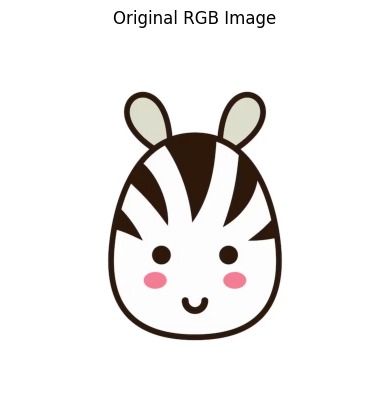

In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# URL for the raw image file
image_url = "https://raw.githubusercontent.com/thimarArda/BinX_AI_-_ML_Training/refs/heads/main/Week7_CNNs_RNN_Transformers/Day%201%20%E2%80%94%20Sprint%202%20Planning%20%26%20Convolutional%20Neural%20Networks/images/sample%202.avif"

# Fetch the image from the URL
response = requests.get(image_url)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

# Open the image using BytesIO
image = Image.open(BytesIO(response.content)).convert("RGB")

image_array = np.array(image)

print(image_array.shape)

plt.imshow(image_array)
plt.axis("off")
plt.title("Original RGB Image")
plt.show()

### 2.  Applying an Edge-Detection Filter

A convolution filter (kernel) is a small matrix of weights used to detect patterns in an image. Since my image has three RGB channels `(740, 740, 3)`, I use a `3 × 3 × 3` filter.

The values in the filter determine which patterns it responds to. For example, an edge-detection filter uses positive and negative values to detect **changes in pixel intensity**, which usually represent edges.

The filter slides across the image and, at each position, multiplies its values by the corresponding pixel values and sums the results. This produces a **feature map** showing where the detected pattern appears most strongly.

In real CNNs, these filter values are learned automatically during training. Here, I define the filter manually to understand how convolution works.


In [3]:
edge_filter = np.array([
    [
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ],
    [
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ],
    [
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ]
])

### 3. Perform the convolution on the image

In [7]:
height, width, channels = image_array.shape

filter_size = 3

feature_map = np.zeros(
    (height - filter_size + 1,
     width - filter_size + 1)
)

for i in range(height - filter_size + 1):
    for j in range(width - filter_size + 1):

        # Get a 3×3×3 region
        region = image_array[
            i:i+filter_size,
            j:j+filter_size,
            :
        ]

        # Multiply with filter and sum
        value = np.sum(region * edge_filter)

        feature_map[i, j] = value

### 4. Visualize the results

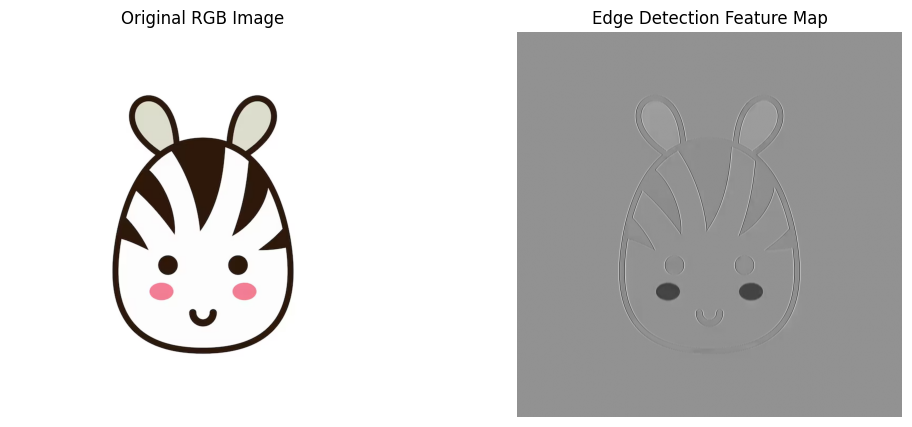

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title("Original RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(feature_map, cmap="gray")
plt.title("Edge Detection Feature Map")
plt.axis("off")

plt.show()

### **Results**

The filter highlights the zebra's outline by detecting sharp changes in color or intensity. In the feature map, edges like the head, ears, and stripes show up as bright or dark lines, while flat areas like the background turn neutral gray. This confirms the filter successfully identified where pixel brightness changes, making the overall shape stand out.



---



## **Exercise 2 :** Explain, in Markdown, why the same filter across the whole image needs far fewer weights than a dense layer.

One of CNN's specialities is **parameter sharing**, where a CNN uses the **same filter and weights across the entire image** instead of learning different weights for every location. In my zebra example, the same edge-detection filter is reused as it moves across different parts of the image, allowing it to detect the zebra's edges and patterns wherever they appear. This greatly **reduces the number of parameters** and makes CNNs more efficient than fully connected networks.

#### **Dense vs. Convolutional Layer**

For my **740 × 740 RGB zebra image**, a Dense layer would first flatten the image into **1,642,800 values**. Connecting these to 1,000 neurons would require over **1.6 billion weights**, making it very inefficient.

In contrast, my `3 × 3 × 3` convolution filter has only **27 weights**, and the same weights are reused across the entire image. This **parameter sharing** makes CNNs much more efficient for image processing.

----

# **References**

- [The Use of CNN in Artificial Intelligence Algorithm for Image Processing](https://svitla.com/blog/cnn-for-image-processing/)

- [Image classification](https://deeplearningwithpython.io/chapters/chapter08_image-classification/)